In [1]:
# Importações
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

# visualizar parâmetros
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## Criando os Borrões Gaussianos com barras aleatórias

In [10]:
nGauss = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# Variando os pesos suavemente
# cada imagem será um Gaussian com um peso diferente, ou seja, uma largura diferente
widths = np.linspace(2,20,nGauss)

# inicializando os tensores com imagens
images = torch.zeros(nGauss,1,imgSize,imgSize)

for i in range(nGauss):

    # Criando os Gaussianos com centros aleatórios
    ro = 1.5*np.random.randn(2) # ro = random offset
    G = np.exp(-((X-ro[0])**2 + (Y-ro[1])**2) / widths[i])

    # adicionando ruído
    G = G + np.random.randn(imgSize,imgSize)/5

    # Adicionando uma barra aleatória
    i1 = np.random.choice(np.arange(2,28)) # posição da barra
    i2 = np.random.choice(np.arange(2,6)) # largura da barra
    # A barra pode ser horizontal ou vertical, escolhida aleatoriamente
    if np.random.randn()>0:
        G[i1:i1+i2,] = 1
    else:
        G[:,i1:i1+i2] = 1
    
    # Adicionando a imagem ao tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)

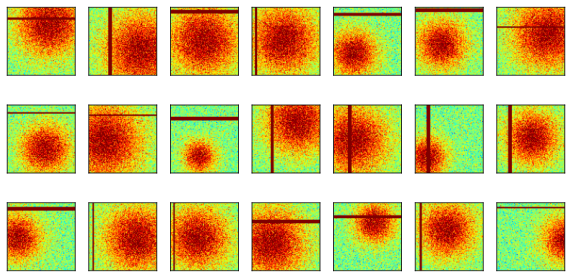

In [11]:
# Visualizando algumas imagens
fig, axs = plt.subplots(3,7,figsize=(10,5))

for i,ax in enumerate(axs.flatten()):
    whichpic = np.random.randint(nGauss)
    G = np.squeeze( images[whichpic,:,:] )
    ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### Criando o modelo

In [15]:
# Criando a classe do modelo
def makeTheNet():

    class gausnet(nn.Module):
        def __init__(self):
            super().__init__()

            # Encondig layer
            self.enc = nn.Sequential(
                nn.Conv2d(1,6,3,padding=1), # 1 input channel, 6 output channels, kernel size 3, padding 1
                nn.ReLU(),
                nn.MaxPool2d(2,2), # kernel size 2, stride 2
                nn.Conv2d(6,4,3,padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2,2)
            )

            # Decoding layer
            self.dec = nn.Sequential(
                # parametros selecionados para que a imagem volte ao tamanho original
                nn.ConvTranspose2d(4,6,3,2),
                nn.ReLU(),
                nn.ConvTranspose2d(6,1,3,2)
            )

        def forward(self,x):
            return self.dec( self.enc(x) )
        

    # Criando a instância do modelo
    net = gausnet()

    # Loss
    lossfun = nn.MSELoss()

    # Otimizador
    optimizer = torch.optim.Adam(net.parameters(),lr=0.001)

    return net, lossfun, optimizer

 
torch.Size([10, 1, 91, 91])


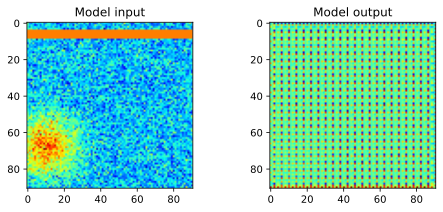

In [16]:
# Testando o modelo
net, lossfun, optimizer = makeTheNet()

yHat = net(images[:10,:,:,:])

# checando o tamanho da saída
print(' ')
print(yHat.shape)

# vamos ver como elas ficam
fig,ax = plt.subplots(1,2,figsize=(8,3))
ax[0].imshow(torch.squeeze(images[0,0,:,:]).detach(),cmap='jet')
ax[0].set_title('Model input')
ax[1].imshow(torch.squeeze(yHat[0,0,:,:]).detach(),cmap='jet')
ax[1].set_title('Model output')

plt.show()

In [17]:
# Contando o número de parâmetros
summary(net,(1,imgSize,imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.24
Params size (MB): 0.00
Estimated Total Size (MB): 1.27
---------------------------------------------------

### Função para treinar o modelo (Dessa vez escolhi fazer sem DataLoader)

In [18]:
# Função para treinar o modelo

def func2trainTheModel():

    # número de épocas
    nEpochs = 500

    # Criando o modelo
    net, lossfun, optimizer = makeTheNet()

    # inicializando o vetor de perdas
    losses = torch.zeros(nEpochs)

    # Loop de treinamento
    for epochi in range(nEpochs):

        # pegando um set de imagens aleatórias a cada época
        pics2use = np.random.choice(nGauss,size=32,replace=False)
        X = images[pics2use,:,:,:]

        # Forward pass e loss
        yHat = net(X)
        loss = lossfun(yHat,X)
        losses[epochi] = loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # fim das épocas

    # output
    return losses, net

### Rodando o modelo e vendo os resultados

In [19]:
# Testando o modelo com os dados
losses, net = func2trainTheModel()

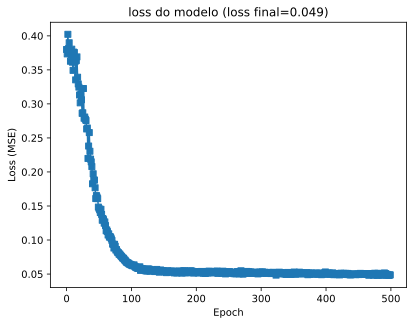

In [20]:
plt.plot(losses, 's-',label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('loss do modelo (loss final=%.3f)' %losses[-1])

plt.show()

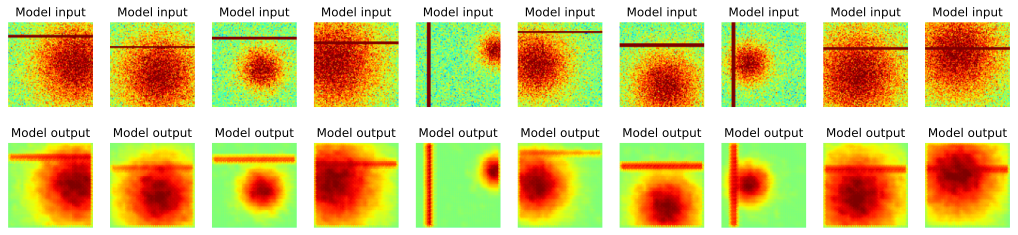

In [ ]:
# visualizando algumas imagens de entrada e saída do modelo

pics2use = np.random.choice(nGauss,size=32,replace=False)
X = images[pics2use,:,:,:]
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(18,4))

for i in range(10):
  
  G = torch.squeeze( X[i,0,:,:] ).detach()
  O = torch.squeeze( yHat[i,0,:,:] ).detach()
  
  axs[0,i].imshow(G,vmin=-1,vmax=1,cmap='jet')
  axs[0,i].axis('off')
  axs[0,i].set_title('Model input')

  axs[1,i].imshow(O,vmin=-1,vmax=1,cmap='jet')
  axs[1,i].axis('off')
  axs[1,i].set_title('Model output')

plt.show()

'''
Podemos ver que o modelo reduzio significativamente o ruído das imagens, 
mas deixou as barras, indicando que o modelo aprendeu, de certo modo, que
as barras são parte do sinal, ou seja, que elas não são ruído.
Entretanto, é possivel realizar ajustes no modelo para que ele aprenda a remover as barras também, 
mas isso fica para outro notebook.
'''